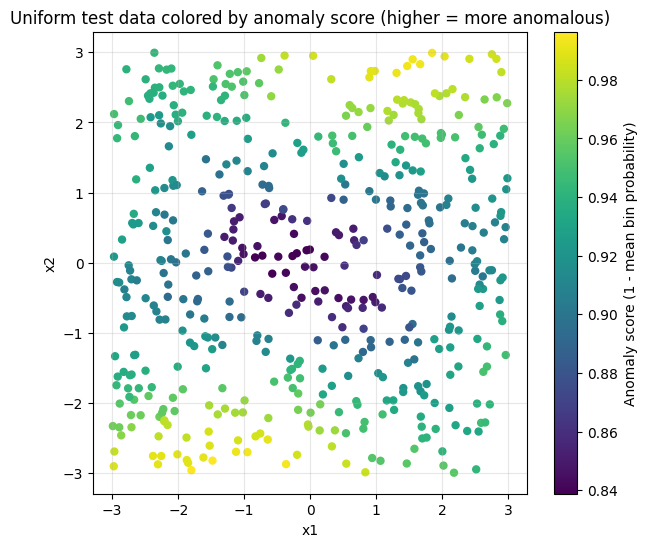

In [1]:
#-------------------------EX1-------------------------------------

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

rng = np.random.default_rng(42)

X_train, _ = make_blobs(
    n_samples=500,
    n_features=2,
    centers=1,
    cluster_std=1.0,
    center_box=(0.0, 0.0),
    random_state=42
)

k = 5
proj = rng.multivariate_normal(mean=[0, 0], cov=np.eye(2), size=k) 
proj = proj / np.linalg.norm(proj, axis=1, keepdims=True)          

Z_train = X_train @ proj.T  

n_bins = 30
hists = []
bin_edges_list = []

for j in range(k):
    z = Z_train[:, j]
    
    zmin, zmax = z.min(), z.max()
    pad = 0.5 * (zmax - zmin + 1e-9)  
    hist_range = (zmin - pad, zmax + pad)

    counts, bin_edges = np.histogram(z, bins=n_bins, range=hist_range)
    
    probs = counts / counts.sum()  
    
    hists.append(probs)
    bin_edges_list.append(bin_edges)

hists = np.array(hists)  

def loda_simple_score(X):
    Z = X @ proj.T  
    scores = np.zeros(X.shape[0], dtype=float)

    for j in range(k):
        probs = hists[j]
        edges = bin_edges_list[j]

        idx = np.digitize(Z[:, j], edges) - 1

        idx = np.clip(idx, 0, n_bins - 1)

        scores += probs[idx]

    scores /= k
    return scores

X_test = rng.uniform(low=-3, high=3, size=(500, 2))

test_prob_score = loda_simple_score(X_test)

test_anomaly_score = 1.0 - test_prob_score

plt.figure(figsize=(7, 6))
sc = plt.scatter(X_test[:, 0], X_test[:, 1], c=test_anomaly_score, s=25)
plt.title("Uniform test data colored by anomaly score (higher = more anomalous)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.colorbar(sc, label="Anomaly score (1 - mean bin probability)")
plt.grid(True, alpha=0.3)
plt.show()


In [2]:
!pip install torch


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


c:\Users\AcerV\ad-lab01\.venv\lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\AcerV\ad-lab01\.venv\lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\AcerV\ad-lab01\.venv\lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\AcerV\ad-lab01\.venv\lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\AcerV\ad-lab01\.venv\lib\site-packages\torch\utils\data\dataloader.py:6

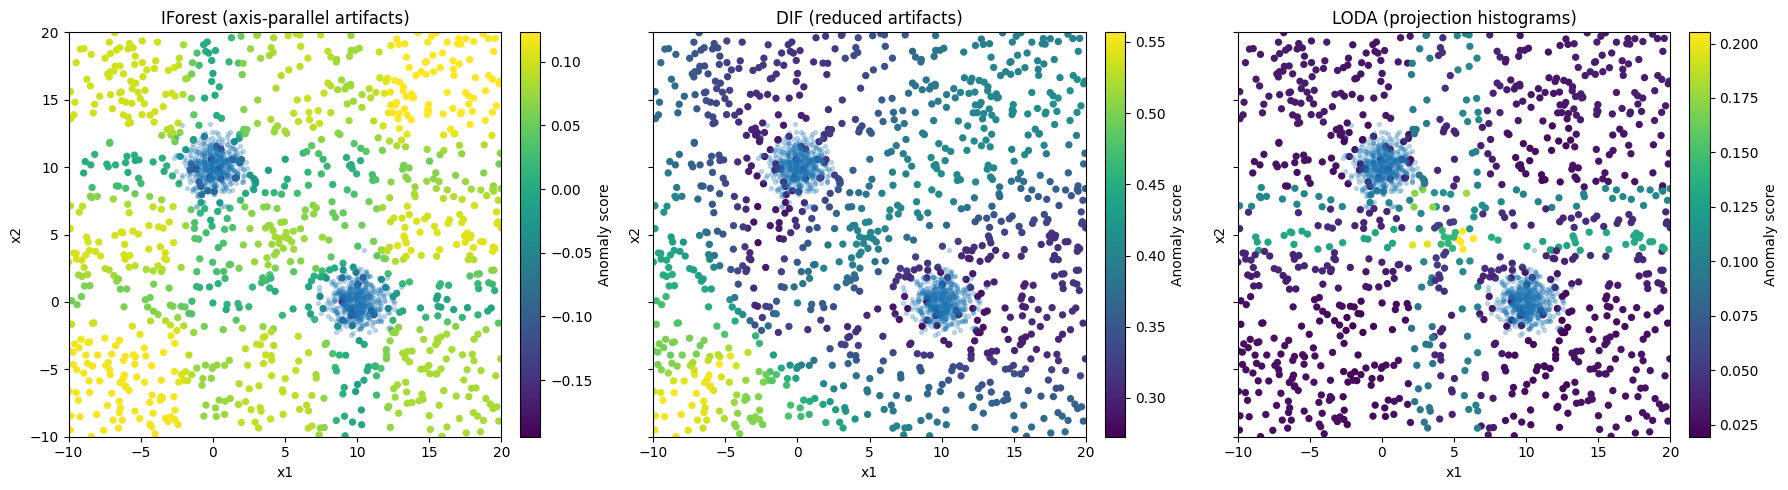

In [7]:
#-------------------------EX2-------------------------------------

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

from pyod.models.iforest import IForest
from pyod.models.dif import DIF
from pyod.models.loda import LODA

rng = np.random.default_rng(42)

X_train, _ = make_blobs(
    n_samples=1000,
    n_features=2,
    centers=np.array([[10, 0], [0, 10]]),
    cluster_std=1.0,
    random_state=42
)

contamination = 0.02

X_test = rng.uniform(low=-10, high=20, size=(1000, 2))

def fit_and_score(model, Xtr, Xte):
    model.fit(Xtr)
    scores = model.decision_function(Xte)
    return scores

# iforest

iforest = IForest(contamination=contamination, random_state=42)
scores_iforest = fit_and_score(iforest, X_train, X_test)

# dif

dif = DIF(
    contamination=contamination,
    random_state=42
)

scores_dif = fit_and_score(dif, X_train, X_test)

# loda

loda = LODA(contamination=contamination)
scores_loda = fit_and_score(loda, X_train, X_test)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)

models = [
    ("IForest (axis-parallel artifacts)", scores_iforest),
    ("DIF (reduced artifacts)", scores_dif),
    ("LODA (projection histograms)", scores_loda),
]

for ax, (title, scores) in zip(axes, models):
    sc = ax.scatter(X_test[:, 0], X_test[:, 1], c=scores, s=18)
    ax.scatter(X_train[:, 0], X_train[:, 1], s=8, alpha=0.25)  
    ax.set_title(title)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04, label="Anomaly score")

axes[0].set_xlim(-10, 20)
axes[0].set_ylim(-10, 20)

plt.tight_layout()
plt.show()



In [8]:
#----------------------------------EX3-------------------------------------

import numpy as np
from scipy.io import loadmat
from sklearn.model_selection import train_test_split
from pyod.utils.utility import standardizer
from sklearn.metrics import balanced_accuracy_score, roc_auc_score


In [9]:
mat = loadmat("shuttle 1.mat")

if "X" in mat and "y" in mat:
    X = mat["X"]
    y = mat["y"].ravel()
else:
    candidates = {k: v for k, v in mat.items() if not k.startswith("__")}
    X, y = None, None
    for v in candidates.values():
        if isinstance(v, np.ndarray) and v.ndim == 2:
            X = v
            break
    for v in candidates.values():
        if isinstance(v, np.ndarray) and v.size == X.shape[0]:
            y = v.ravel()
            break

print("Loaded:", X.shape, y.shape)
print("Raw labels:", np.unique(y))

uniq = set(np.unique(y).tolist())

if uniq == {-1, 1}:
    y_pyod = ((-1 * y + 1) / 2).astype(int)
elif uniq == {1, 2}:
    y_pyod = (y == 2).astype(int)
else:
    y_pyod = y.astype(int)

print("Outlier rate:", float(np.mean(y_pyod)))


Loaded: (49097, 9) (49097,)
Raw labels: [0 1]
Outlier rate: 0.0715114976475141


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_pyod,
    test_size=0.4,
    random_state=42,
    stratify=y_pyod
)

print("Train:", X_train.shape, "Test:", X_test.shape)


Train: (29458, 9) Test: (19639, 9)


In [11]:
X_train_s, X_test_s = standardizer(X_train, X_test)

In [13]:
def evaluate_model(model, X_train, X_test, y_test):
    model.fit(X_train)
    y_pred = model.predict(X_test)                
    y_scores = model.decision_function(X_test)     
    
    ba = balanced_accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_scores)
    return ba, auc

In [14]:
from pyod.models.iforest import IForest

contamination = float(np.mean(y_train))

iforest = IForest(
    contamination=contamination,
    random_state=42
)

ba_if, auc_if = evaluate_model(iforest, X_train_s, X_test_s, y_test)

print("IForest  - BA:", ba_if)
print("IForest  - ROC AUC:", auc_if)

IForest  - BA: 0.9815349930513078
IForest  - ROC AUC: 0.9965037805728785


In [15]:
from pyod.models.loda import LODA

loda = LODA(contamination=contamination)

ba_loda, auc_loda = evaluate_model(loda, X_train_s, X_test_s, y_test)

print("LODA     - BA:", ba_loda)
print("LODA     - ROC AUC:", auc_loda)

LODA     - BA: 0.46933636669721124
LODA     - ROC AUC: 0.2342705474663248


In [16]:
from pyod.models.dif import DIF

dif = DIF(
    contamination=contamination,
    random_state=42
)

ba_dif, auc_dif = evaluate_model(dif, X_train_s, X_test_s, y_test)

print("DIF      - BA:", ba_dif)
print("DIF      - ROC AUC:", auc_dif)


c:\Users\AcerV\ad-lab01\.venv\lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\AcerV\ad-lab01\.venv\lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\AcerV\ad-lab01\.venv\lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\AcerV\ad-lab01\.venv\lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\AcerV\ad-lab01\.venv\lib\site-packages\torch\utils\data\dataloader.py:6

DIF      - BA: 0.5068757289486656
DIF      - ROC AUC: 0.9598130454176519
